# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [ ]:
import pandas as pd

In [2]:
url = "https://cdn.theforage.com/vinternships/companyassets/tMjbs76F526fF5v3G/L3MQ8f6cYSkfoukmz/1667814300249/customer_booking.csv"
df = pd.read_csv(url, encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [8]:
df.columns
df["booking_complete"].value_counts()
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

## Initial Observations

- No missing values were identified across the dataset
- Features include a mix of numerical and categorical variables
- Further preprocessing will be required for categorical variables before modeling

In [9]:
df["booking_complete"].value_counts(normalize=True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

## Class Imbalance

The dataset is imbalanced, with approximately 85% of observations representing non-completed bookings and only 15% representing completed bookings.

This imbalance can bias the model toward predicting the majority class. Therefore, evaluation metrics such as precision, recall, and F1-score will be more informative than accuracy alone.

In [12]:
from sklearn.linear_model import LogisticRegression
LogisticRegression(class_weight='balanced')

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['booking_complete'])
y = df['booking_complete']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

/Users/rohithsrinivasa/Documents/bike-demand-datascience/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Logistic Regression Setup

A Logistic Regression model was used as the baseline classifier. Because the dataset is imbalanced, class weights were balanced to give more importance to completed bookings. Numerical features were also scaled to improve model convergence and stability.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['booking_complete'])
y = df['booking_complete']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=2000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [17]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[5897 2607]
 [ 367 1129]]
              precision    recall  f1-score   support

           0       0.94      0.69      0.80      8504
           1       0.30      0.75      0.43      1496

    accuracy                           0.70     10000
   macro avg       0.62      0.72      0.62     10000
weighted avg       0.85      0.70      0.74     10000



## Model Performance & Interpretation

The Logistic Regression model achieved a recall of 75% for completed bookings, indicating that it successfully identifies the majority of customers who complete bookings. This is important from a business perspective, as missing potential customers could lead to lost revenue opportunities.

However, the precision for completed bookings is relatively low (30%), meaning that many predicted bookings are false positives. This suggests that while the model is effective at capturing potential bookings, further refinement is needed to improve prediction accuracy.

Overall, the model demonstrates strong potential for identifying booking behavior, with a trade-off between recall and precision.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8504
           1       0.51      0.13      0.20      1496

    accuracy                           0.85     10000
   macro avg       0.69      0.55      0.56     10000
weighted avg       0.81      0.85      0.81     10000



## Model Comparison

A Random Forest model was evaluated to compare performance with Logistic Regression. While Random Forest achieved higher overall accuracy, it performed poorly in identifying completed bookings, with a recall of only 13%.

In contrast, Logistic Regression achieved a much higher recall of 75% for completed bookings, making it significantly more effective at identifying customers likely to complete bookings.

From a business perspective, recall is more critical, as failing to identify potential customers could result in lost revenue opportunities. Therefore, Logistic Regression is the preferred model despite its lower precision.

In [19]:
RandomForestClassifier(class_weight='balanced')

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(10)

route_AKLKUL                0.282765
route_PENTPE                0.261856
booking_origin_Malaysia     0.213926
route_ICNPEN                0.188142
booking_origin_Thailand     0.184470
route_BKIICN                0.180384
wants_extra_baggage         0.177688
route_ICNMLE                0.166679
route_ICNLGK                0.164071
booking_origin_Indonesia    0.161047
dtype: float64

## Key Drivers of Booking Completion

Feature importance analysis highlights that route and booking origin are among the most significant predictors of booking completion, indicating that customer behavior varies by geography and travel patterns.

Specific routes show higher likelihood of conversion, suggesting opportunities for route-level optimization and targeted marketing strategies.

Additionally, customers who select ancillary services such as extra baggage are more likely to complete bookings, indicating stronger purchase intent. This insight can be leveraged to identify high-value customers earlier in the booking process.

## Business Recommendations

- Target customers on high-conversion routes with personalized offers to maximize booking completion rates
- Use add-on selections (e.g., baggage, meals) as early indicators of purchase intent for targeted promotions
- Focus marketing efforts on regions with higher conversion rates to improve overall booking performance

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model, X_train_scaled, y_train,
    cv=5,
    scoring='recall'
)

print("Cross-validation recall scores:", cv_scores)
print("Average recall:", cv_scores.mean())

Cross-validation recall scores: [0.75501672 0.76588629 0.75083612 0.72347536 0.73433584]
Average recall: 0.7459100650176166


## Cross-Validation

Cross-validation was performed to evaluate the model’s generalizability. The model achieved a consistent recall of approximately 74–76% across folds, indicating stable performance in identifying completed bookings.

This suggests that the model is robust and not overly dependent on a specific train-test split.

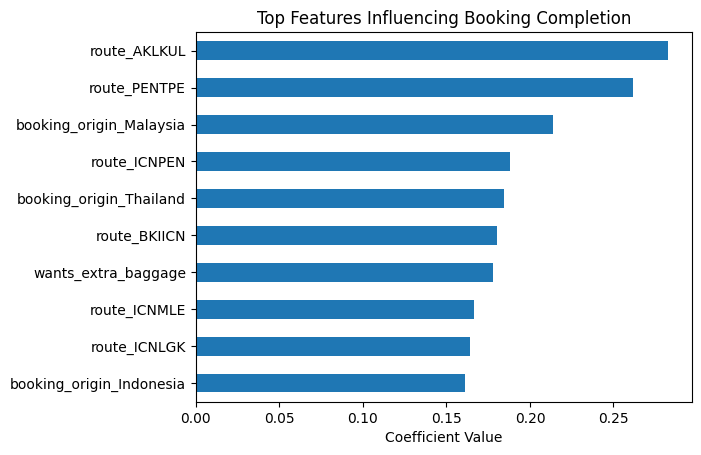

In [23]:
import matplotlib.pyplot as plt

importance.head(10).sort_values().plot(kind='barh')
plt.title("Top Features Influencing Booking Completion")
plt.xlabel("Coefficient Value")
plt.show()

## Feature Importance Interpretation

The visualization highlights the most influential factors driving booking completion.

Route and booking origin emerge as key predictors, indicating that customer behavior varies significantly across regions and travel patterns. Additionally, the selection of ancillary services such as extra baggage is a strong indicator of booking intent.

These insights can be used to guide targeted marketing strategies and improve conversion rates.